# Full Pipeline - VAE Healer + ResNet Expert
Integrate trained Stage A and Stage B modules into one self-healing inference pipeline.

In [1]:
import time
import random
import sys
from pathlib import Path

import numpy as np
import yaml
import torch
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Ensure imports from project root work regardless of notebook working directory.
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import get_dataloaders, NoiseInjector
from src.conv_vae import ConvVAE
from src.classifier import get_classifier
from src.pipeline import SelfHealingPipeline
from src.evaluate import evaluate_pipeline

C:\Users\Akash\AppData\Local\Temp\ipykernel_18708\4046728156.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

models_dir = (project_root / 'models').resolve()
vae_path = models_dir / 'conv_vae_best.pth'
classifier_path = models_dir / 'resnet_classifier.pth'
data_root = (project_root / config['dataset']['root']).resolve()

device = config['training']['device'] if torch.cuda.is_available() else 'cpu'
vae = ConvVAE(latent_dim=config['vae']['latent_dim']).to(device)
classifier = get_classifier(num_classes=config['dataset']['num_classes'], pretrained=False).to(device)

vae.load_state_dict(torch.load(vae_path, map_location=device))
classifier.load_state_dict(torch.load(classifier_path, map_location=device))
vae.eval()
classifier.eval()
print(f'Using data root: {data_root}')

C:\Users\Akash\AppData\Local\Temp\ipykernel_18708\2443349838.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load(vae_path, map_location=devic

Using data root: C:\Users\Akash\Desktop\SelfHealingNN\data\raw


C:\Users\Akash\AppData\Local\Temp\ipykernel_18708\2443349838.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier.load_state_dict(torch.load(classifier_path, map_

In [3]:
pipeline = SelfHealingPipeline(
    vae=vae,
    classifier=classifier,
    vae_outputs_denormalized=bool(config['vae'].get('denormalize_targets', True)),
).to(device)
print(f"Pipeline vae_outputs_denormalized: {pipeline.vae_outputs_denormalized}")
pipeline

Pipeline vae_outputs_denormalized: False


SelfHealingPipeline(
  (vae): ConvVAE(
    (encoder): ConvEncoder(
      (features): Sequential(
        (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): LeakyReLU(negative_slope=0.2, inplace=True)
        (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): LeakyReLU(negative_slope=0.2, inplace=True)
        (9): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (10): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (11): LeakyReLU(negative_slo

Batch top-1 on noisy->healed path: 100.00%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

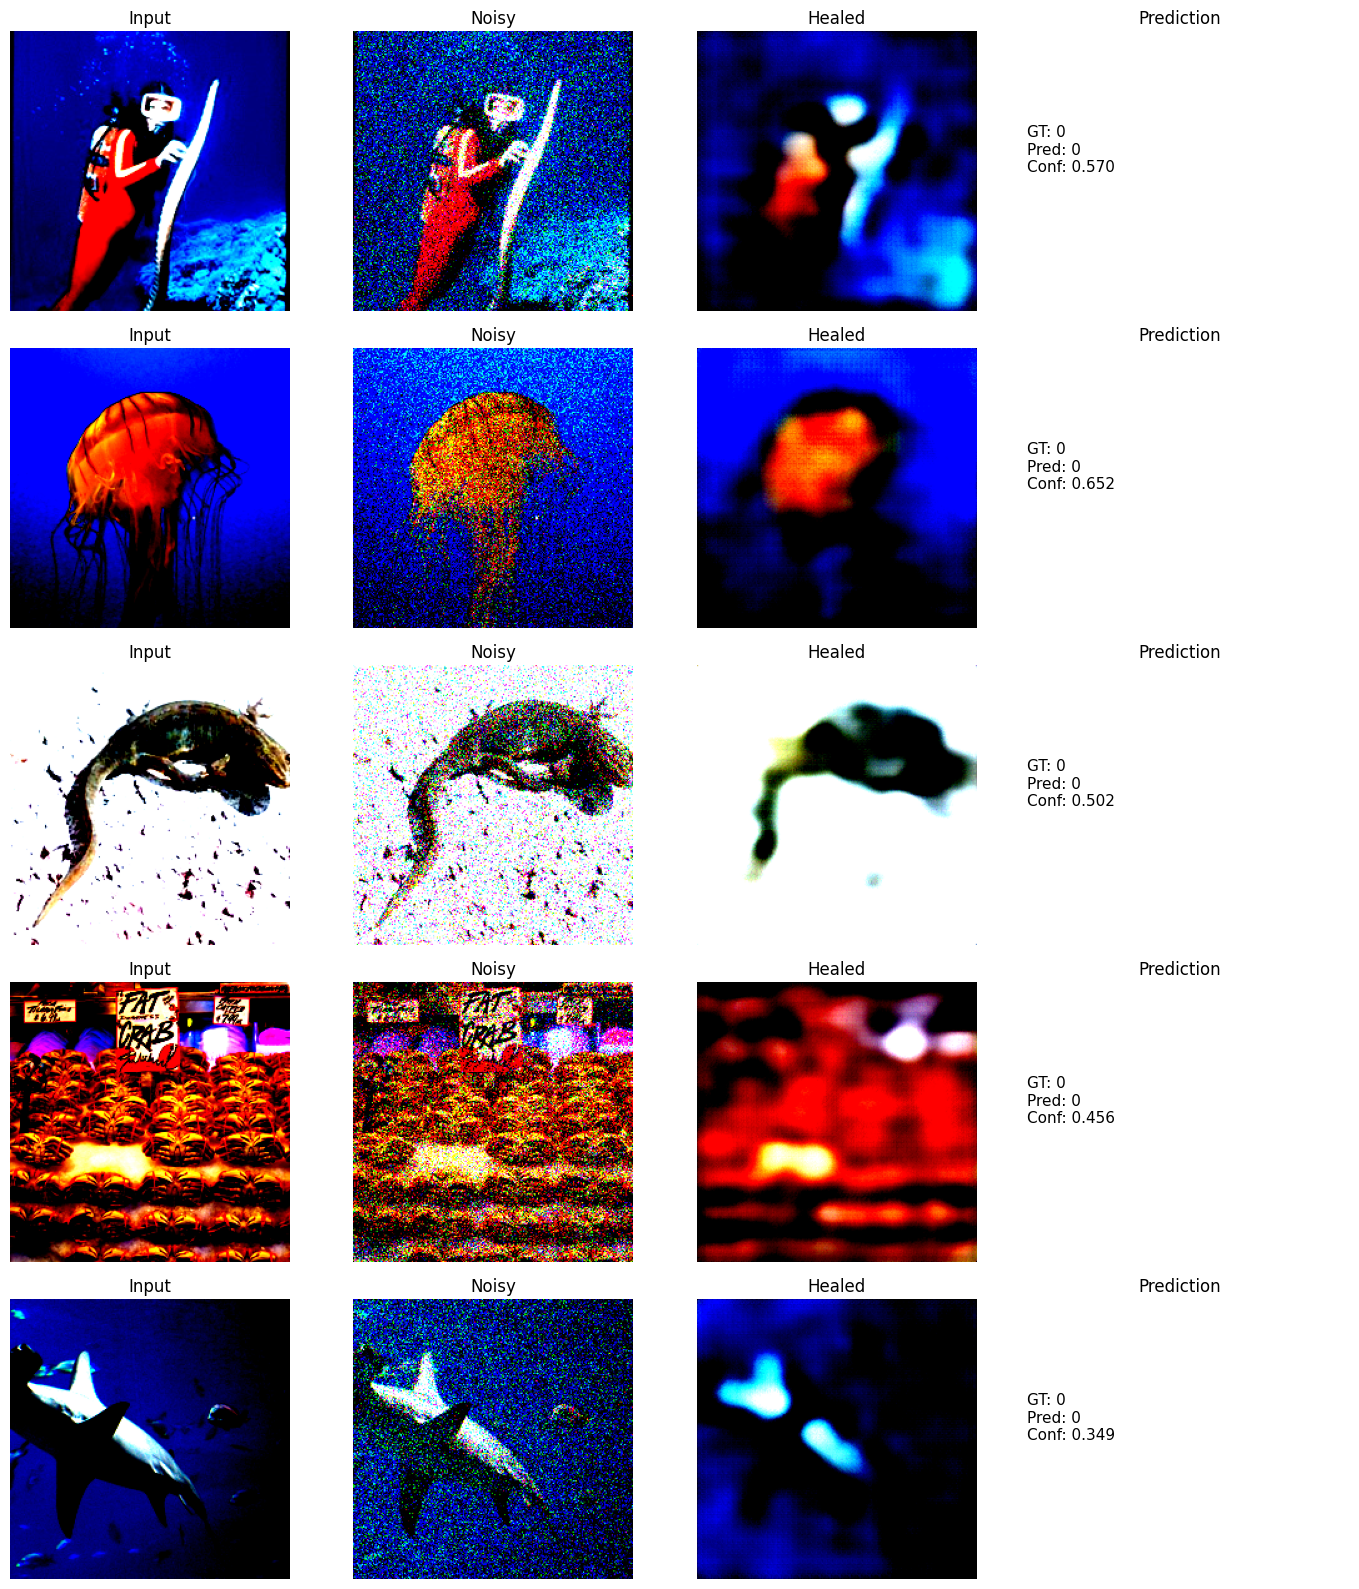

In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    root=str(data_root),
    image_size=config['dataset']['image_size'],
    batch_size=8,
    train_split=config['dataset']['train_split'],
    num_workers=config['training']['num_workers'],
    noisy=False
)

injector = NoiseInjector()
images, labels = next(iter(test_loader))
images = images[:5].to(device)
labels = labels[:5]
noise_std = float(config['noise'].get('gaussian_std', 0.3))
noisy = torch.stack([injector.add_gaussian_noise(img, std=noise_std) for img in images])
preds, confs, healed = pipeline(noisy)

batch_acc = (preds.cpu() == labels).float().mean().item()
print(f'Batch top-1 on noisy->healed path: {100.0 * batch_acc:.2f}%')

fig, axes = plt.subplots(5, 4, figsize=(14, 16))
for i in range(5):
    axes[i, 0].imshow(images[i].detach().cpu().permute(1, 2, 0).numpy(), vmin=-2, vmax=2)
    axes[i, 0].set_title('Input')
    axes[i, 1].imshow(noisy[i].detach().cpu().permute(1, 2, 0).numpy(), vmin=-2, vmax=2)
    axes[i, 1].set_title('Noisy')
    axes[i, 2].imshow(healed[i].detach().cpu().permute(1, 2, 0).numpy())
    axes[i, 2].set_title('Healed')
    axes[i, 3].text(
        0.05,
        0.5,
        f'GT: {int(labels[i])}\nPred: {int(preds[i])}\nConf: {float(confs[i]):.3f}',
        fontsize=11,
    )
    axes[i, 3].set_title('Prediction')
    for j in range(4):
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [5]:
warmup = noisy[:1]
_ = pipeline(warmup)

runs = 30
start = time.perf_counter()
for _ in range(runs):
    _ = pipeline(warmup)
elapsed_ms = (time.perf_counter() - start) * 1000 / runs
print(f'Average end-to-end inference time: {elapsed_ms:.2f} ms / sample')

with torch.no_grad():
    start = time.perf_counter()
    for _ in range(runs):
        healed_only = pipeline.heal(warmup)
    vae_ms = (time.perf_counter() - start) * 1000 / runs

    start = time.perf_counter()
    for _ in range(runs):
        _ = pipeline.classify(healed_only)
    cls_ms = (time.perf_counter() - start) * 1000 / runs

print(f'VAE stage latency: {vae_ms:.2f} ms / sample')
print(f'Classifier stage latency: {cls_ms:.2f} ms / sample')

Average end-to-end inference time: 5.38 ms / sample
VAE stage latency: 2.62 ms / sample
Classifier stage latency: 3.93 ms / sample


In [6]:
batch = noisy
with torch.no_grad():
    pred_b, conf_b, healed_b = pipeline(batch)

batch_top1 = (pred_b.cpu() == labels).float().mean().item()
print('Batch size:', batch.size(0))
print('Ground Truth:', labels.tolist())
print('Predictions:', pred_b.tolist())
print('Confidences:', [round(float(c), 4) for c in conf_b])
print(f'Batch Top-1: {100.0 * batch_top1:.2f}%')
print('Healed batch shape:', tuple(healed_b.shape))

Batch size: 5
Ground Truth: [0, 0, 0, 0, 0]
Predictions: [0, 0, 0, 0, 0]
Confidences: [0.6026, 0.6108, 0.4571, 0.5114, 0.4134]
Batch Top-1: 100.00%
Healed batch shape: (5, 3, 224, 224)


[EvalWarn] At high noise (0.7): Healing accuracy (96.31%) <= No-healing accuracy (96.31%). VAE is not improving classifier performance. Check tensor ranges and VAE training config.
[EvalWarn] At high noise (0.7): Healing confidence (0.3933) much lower than no-healing confidence (0.5761). VAE outputs may be in wrong tensor space.


,noise,clean,noHealing,withHealing,clean_top5,noHealing_top5,withHealing_top5,clean_conf,noHealing_conf,withHealing_conf
0,0.1,96.312204,96.312204,96.312204,100.0,100.0,100.0,0.869173,0.851335,0.437907
1,0.2,96.312204,96.312204,96.312204,100.0,100.0,100.0,0.869173,0.827799,0.440781
2,0.3,96.312204,96.312204,96.312204,100.0,100.0,100.0,0.869173,0.785515,0.438477
3,0.5,96.312204,96.312204,96.312204,100.0,100.0,100.0,0.869173,0.666659,0.418383
4,0.7,96.312204,96.312204,96.312204,100.0,100.0,100.0,0.869173,0.576098,0.393284


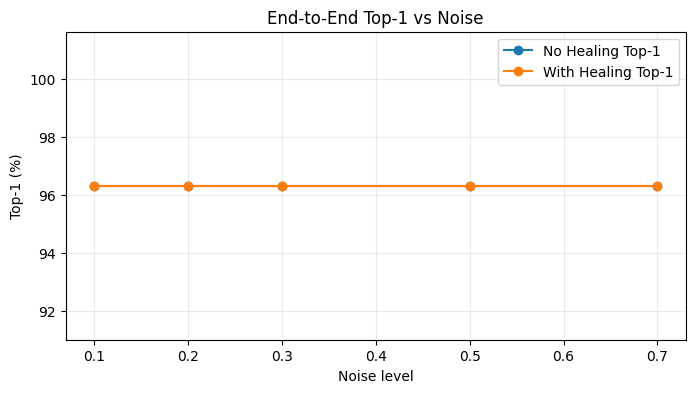

Saved quick pipeline metrics to: C:\Users\Akash\Desktop\SelfHealingNN\outputs\results\pipeline_quick_metrics.csv


In [7]:
# End-to-end performance curve (quick integration benchmark)
quick_results = evaluate_pipeline(
    vae=vae,
    classifier=classifier,
    test_loader=test_loader,
    device=device,
    noise_levels=[0.1, 0.2, 0.3, 0.5, 0.7],
    vae_outputs_denormalized=bool(config['vae'].get('denormalize_targets', True)),
    debug_ranges=False,
)

quick_df = pd.DataFrame(quick_results)
display(quick_df)

plt.figure(figsize=(8, 4))
plt.plot(quick_df['noise'], quick_df['noHealing'], marker='o', label='No Healing Top-1')
plt.plot(quick_df['noise'], quick_df['withHealing'], marker='o', label='With Healing Top-1')
plt.xlabel('Noise level')
plt.ylabel('Top-1 (%)')
plt.title('End-to-End Top-1 vs Noise')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

quick_path = project_root / 'outputs' / 'results' / 'pipeline_quick_metrics.csv'
quick_df.to_csv(quick_path, index=False)
print(f'Saved quick pipeline metrics to: {quick_path.resolve()}')

## Summary
The integration notebook now includes a quick end-to-end robustness curve and exports `outputs/results/pipeline_quick_metrics.csv`.
For full reporting, run Notebook 5 after training.